These are the main Features/Columns available in the dataset :
*   Date/Time - The timestamp when the weather observation was recorded. Format: M/D/YYYY H:MM.
*   Temp_C - The air temperature in degrees Celsius at the time of observation.

*   Dew Point Temp_C - The temperature at which air becomes saturated with (dew point), also measured in degrees Celsius.
moisture

*   Rel Hum_% - The relative humidity, expressed as a percentage (%), indicating how much moisture is in the air compared to the maximum it could hold at that temperature.

*   Wind Speed_km/h - The speed of the wind at the time of observation, measured in kilometers per hour.

*   Visibility_km - The distance one can clearly see, measured in kilometers. Lower values often indicate fog or precipitation.

*   Press_kPa - Atmospheric pressure at the time of observation, measured in kilopascals (kPa).

*   Weather - A text description of the observed weather conditions, such as "Fog", "Rain", or "Snow".







In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import pylab
from sklearn.impute import KNNImputer
!pip install pingouin
import pingouin as pg
import math
import matplotlib.pyplot as plt
%load_ext rpy2.ipython
data=pd.read_csv("Wdata.csv")
data['Date/Time']=pd.to_datetime(data['Date/Time'])
data.head(10000)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 5.2 MB/s eta 0:00:00


,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,2012-01-01 02:00:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,2012-01-01 03:00:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,2012-01-01 04:00:00,-1.5,-3.3,88,7,4.8,101.23,Fog
...,...,...,...,...,...,...,...,...
8779,2012-12-31 19:00:00,0.1,-2.7,81,30,9.7,100.13,Snow
8780,2012-12-31 20:00:00,0.2,-2.4,83,24,9.7,100.03,Snow
8781,2012-12-31 21:00:00,-0.5,-1.5,93,28,4.8,99.95,Snow
8782,2012-12-31 22:00:00,-0.2,-1.8,89,28,9.7,99.91,Snow


# Information about data:

In [2]:
Data=pd.DataFrame(columns=['name','type','max','min','mean','number_of_passes'])
for column_name in data.columns:
  try:
    sdsd=data[column_name].mean()
  except:
    sdsd=np.nan
  Data.loc[len(Data)]=[column_name,type(data[column_name].dtype),data[column_name].max(),data[column_name].min(),sdsd,data[column_name].isnull().sum()]
Data

,name,type,max,min,mean,number_of_passes
0,Date/Time,<class 'numpy.dtypes.DateTime64DType'>,2012-12-31 23:00:00,2012-01-01 00:00:00,2012-07-01 23:30:00,0
1,Temp_C,<class 'numpy.dtypes.Float64DType'>,33.0,-23.3,8.798144,0
2,Dew Point Temp_C,<class 'numpy.dtypes.Float64DType'>,24.4,-28.5,2.555294,0
3,Rel Hum_%,<class 'numpy.dtypes.Int64DType'>,100,18,67.431694,0
4,Wind Speed_km/h,<class 'numpy.dtypes.Int64DType'>,83,0,14.945469,0
5,Visibility_km,<class 'numpy.dtypes.Float64DType'>,48.3,0.2,27.664447,0
6,Press_kPa,<class 'numpy.dtypes.Float64DType'>,103.65,97.52,101.051623,0
7,Weather,<class 'numpy.dtypes.ObjectDType'>,"Thunderstorms,Rain,Fog",Clear,NaN,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date/Time         8784 non-null   datetime64[ns]
 1   Temp_C            8784 non-null   float64       
 2   Dew Point Temp_C  8784 non-null   float64       
 3   Rel Hum_%         8784 non-null   int64         
 4   Wind Speed_km/h   8784 non-null   int64         
 5   Visibility_km     8784 non-null   float64       
 6   Press_kPa         8784 non-null   float64       
 7   Weather           8784 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 549.1+ KB


# Density-graphics

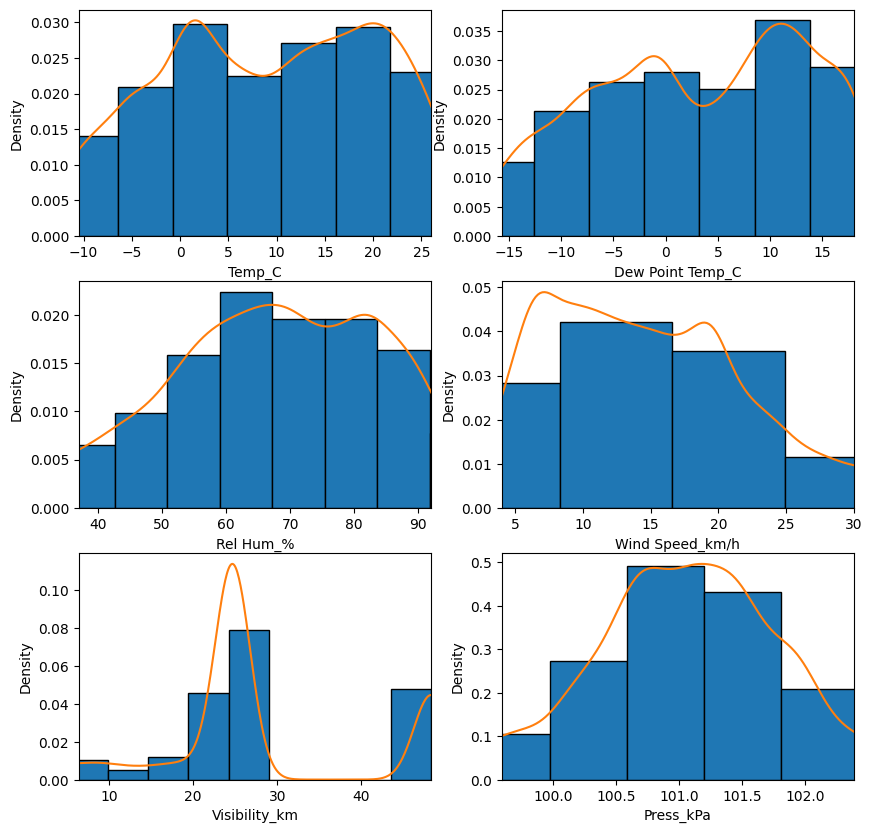

In [4]:
for i in range(1,7):
  pylab.subplot(3,2,i)
  col_name=data.columns[i]
  ax=data[col_name].plot.hist(density=True, edgecolor='black', xlim=[data[col_name].quantile(0.05),data[col_name].quantile(0.95)],figsize=(10,10))
  data[col_name].plot.density(ax=ax)
  ax.set_xlabel(col_name)

# CD-Plot:

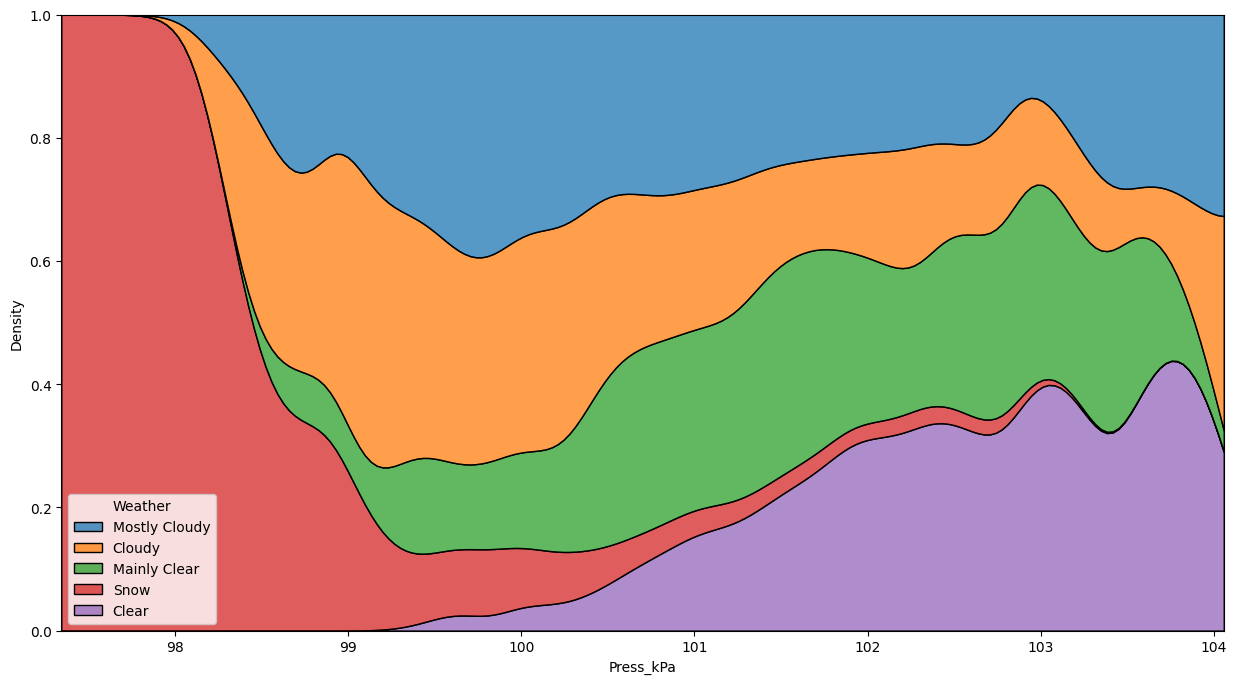

In [5]:
fig, axes = plt.subplots(figsize=(15, 8), nrows=1, ncols=1)

List = data.Weather.value_counts().sort_values().index.tolist()[-5:]
Data5 = data[data.Weather.isin(List)]

sns.kdeplot(data=Data5,x="Press_kPa",hue="Weather",multiple="fill",ax=axes)
plt.show()

# Strip-Plot

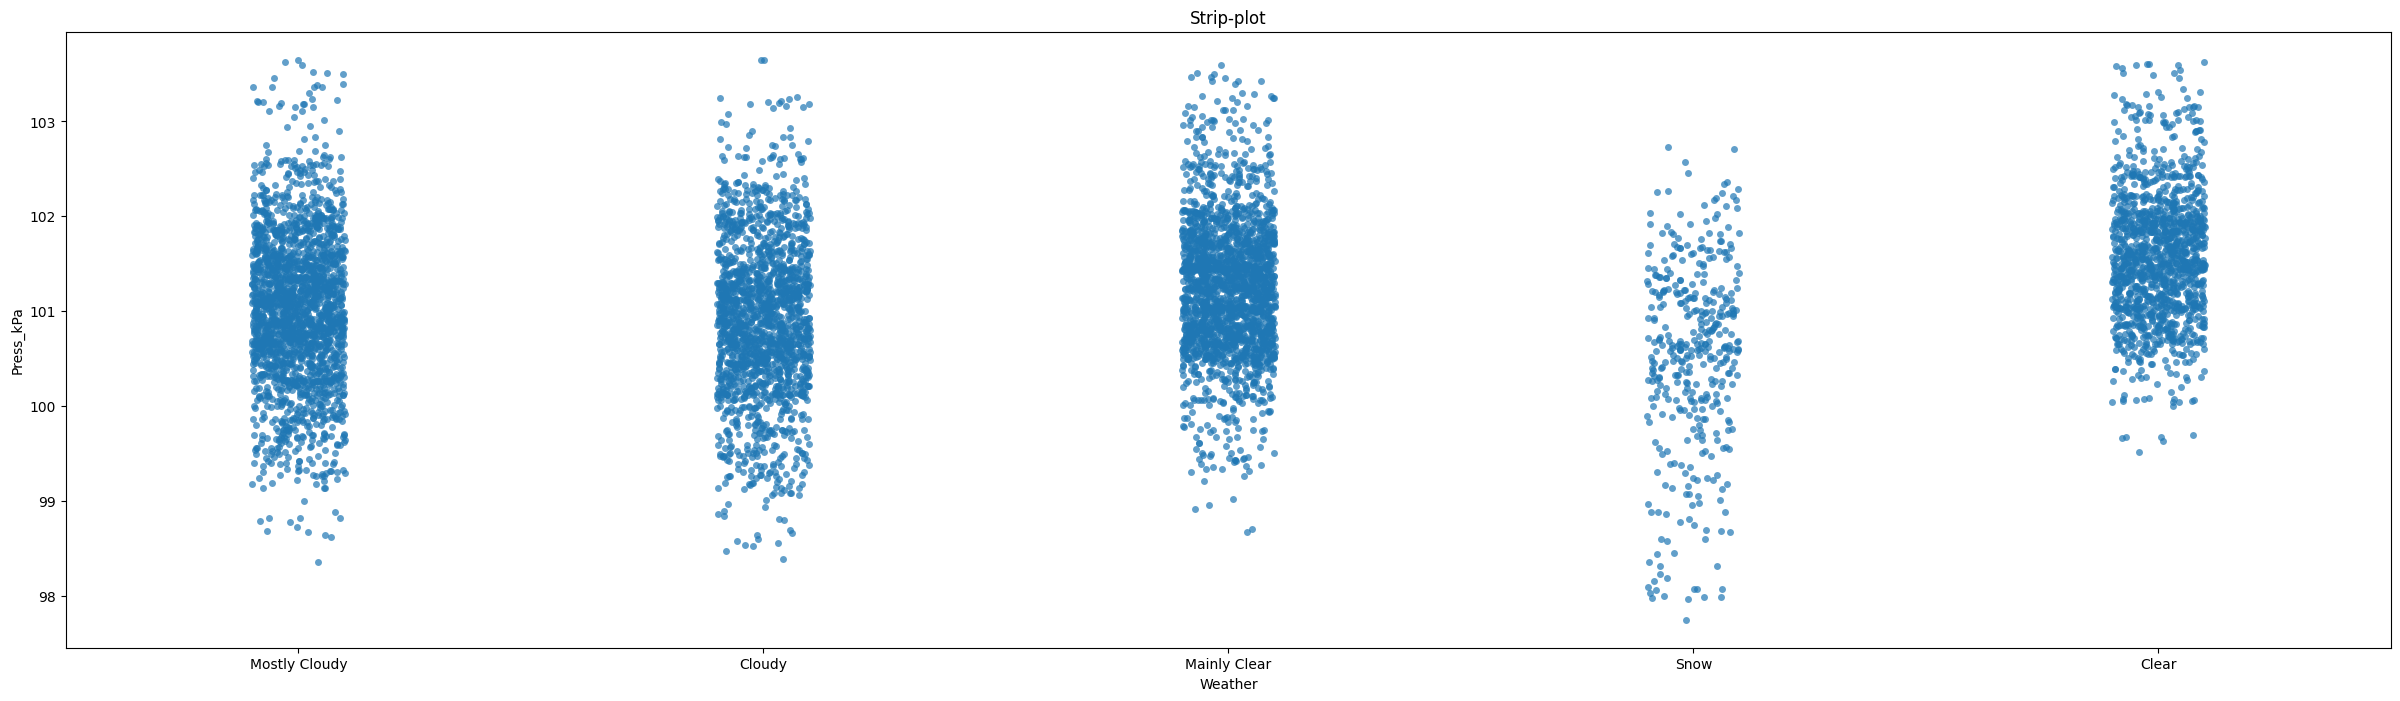

In [6]:
plt.figure(figsize=(30,8))
ND=100

sns.stripplot(data=Data5, x='Weather', y='Press_kPa', jitter=True, alpha=0.7)
plt.title("Strip-plot")
plt.show()


# dotchart

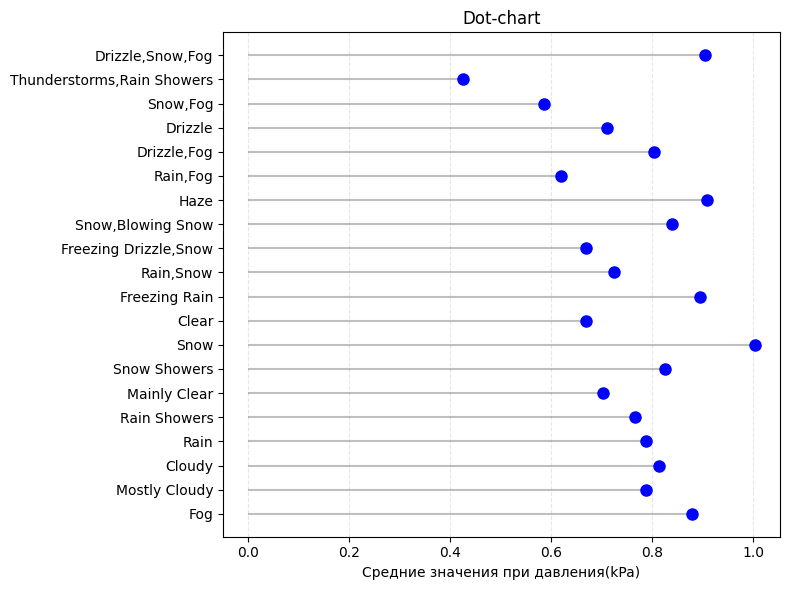

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

List = data.Weather.value_counts().sort_values().index.tolist()[-20:]
Data15 = data[data.Weather.isin(List)]

categories=Data15.Weather.unique()
values=[Data15[Data15['Weather']==i]['Press_kPa'].std() for i in categories]

for i, (cat, val) in enumerate(zip(categories, values)):
    ax.hlines(y=i, xmin=0, xmax=val, color='gray', alpha=0.5)
    ax.plot(val, i, 'o', color='blue', markersize=8)

ax.set_yticks(range(len(categories)))
ax.set_yticklabels(categories)
ax.set_xlabel('Средние значения при давления(kPa)')
ax.set_title('Dot-chart')
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Box-Plot:

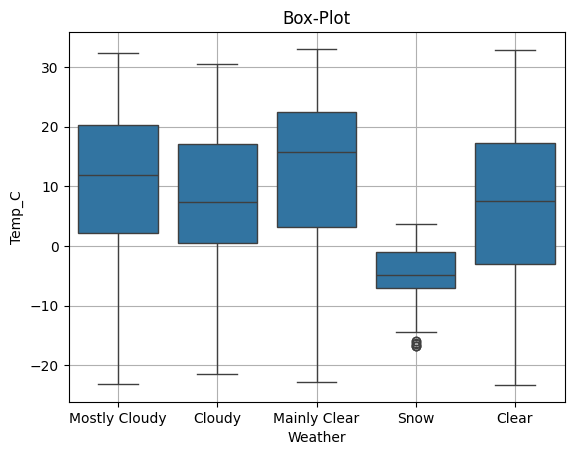

In [8]:
sns.boxplot(data = Data5, x = "Weather", y = "Temp_C")
plt.title("Box-Plot")
plt.grid(True)


# Emissions tests


Согласно критерию Граббса, выбросов нет
Согласно Q-тесту Диксона, в выборке нет выбросов


Text(0.5, 1.0, 'Q-Test')

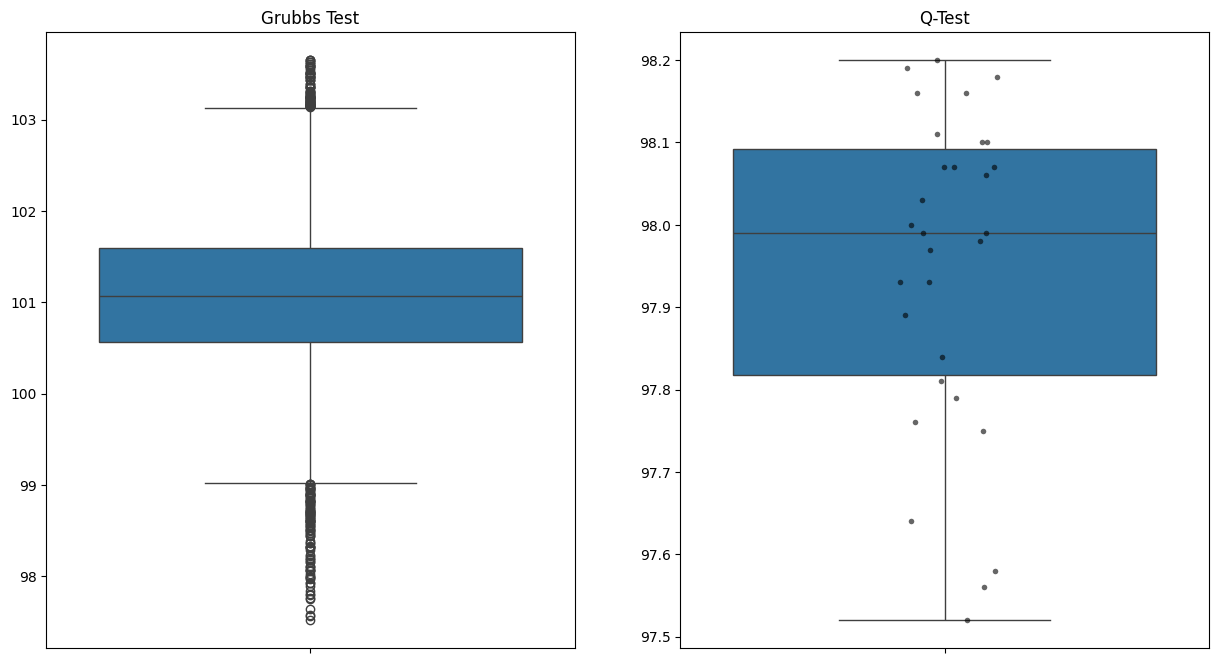

In [9]:
#Grubbs
from scipy import stats
alpha=0.05
Datag=data.Press_kPa.values
N=Datag.shape[0]
fig,axes=plt.subplots(figsize=(15,8),nrows=1,ncols=2)
K=stats.t.ppf(1-alpha/(2*N),N-2)
K=(N-1)/(N**0.5)*((K*K/(N-2+K*K))**0.5)

mean=Datag.mean()
G=max([abs(i-mean) for i in Datag])/Datag.std()
print("Согласно критерию Граббса, "+("выбросы есть" if G>K else "выбросов нет"))

sns.boxplot(data = Datag,ax=axes[0])
axes[0].set_title('Grubbs Test')

#Dixon's Q-test
Datag=sorted(Datag)[0:30]

Qmax=(Datag[-1]-Datag[-2])/(Datag[-1]-Datag[0])
Qmin=(Datag[1]-Datag[0])/(Datag[-1]-Datag[0])
Z=0.26   #критическое значение для Q-теста Диксона при N=30 и alpha=0.05
print("Согласно Q-тесту Диксона, в выборке","есть выброс" if Qmax>Z or Qmin>Z else"нет выбросов")
sns.boxplot(data = Datag,ax=axes[1])


sns.stripplot(data=Datag, jitter=True, color='black', size=4, alpha=0.6)
axes[1].set_title('Q-Test')


Согласно критерию Граббса, выбросы есть
Согласно Q-тесту Диксона, в выборке есть выброс


Text(0.5, 1.0, 'Q-Test')

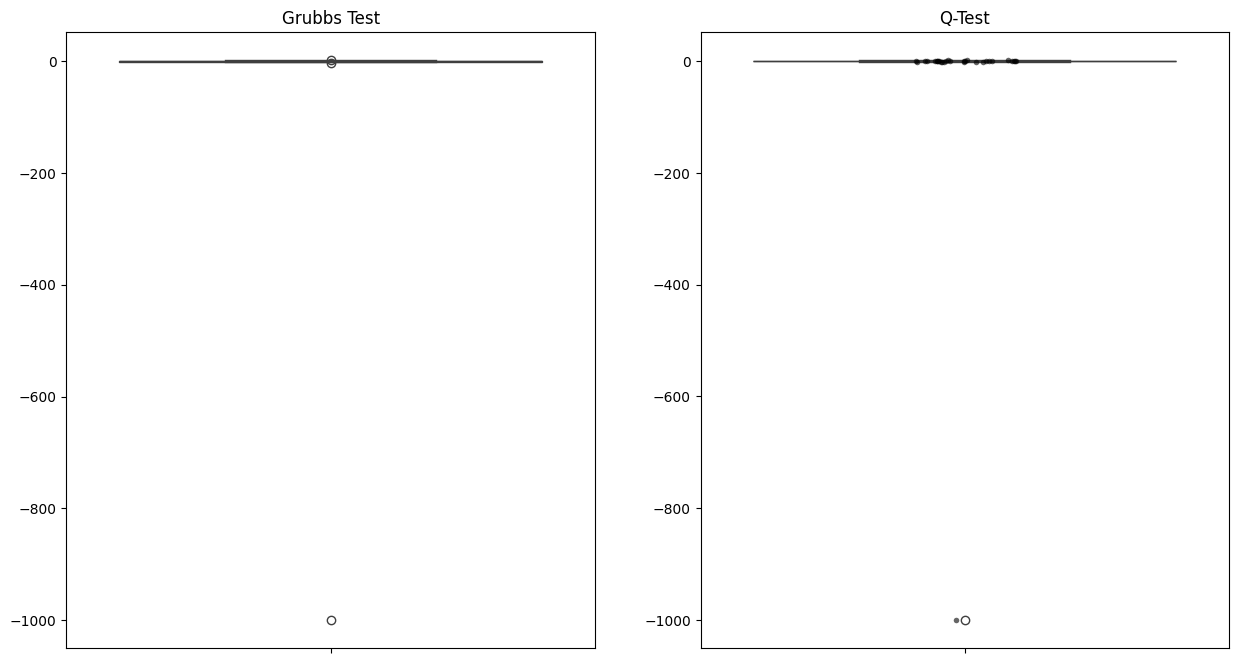

In [10]:


# Генерация выборки из нормального распределения
np.random.seed(42)
Datag = np.random.normal(0, 1, 100)
Datag[0]=-1000
alpha = 0.05
N = Datag.shape[0]
fig, axes = plt.subplots(figsize=(15, 8), nrows=1, ncols=2)

# Критерий Граббса
K = stats.t.ppf(1 - alpha / (2 * N), N - 2)
K = (N - 1) / (N ** 0.5) * ((K * K / (N - 2 + K * K)) ** 0.5)

mean = Datag.mean()
G = max([abs(i - mean) for i in Datag]) / Datag.std()
print("Согласно критерию Граббса, "+("выбросы есть" if G>K else "выбросов нет"))

sns.boxplot(data = Datag, ax=axes[0])
axes[0].set_title('Grubbs Test')

# Q-тест Диксона
Datag_sorted = Datag[0:30]
Qmax = (Datag_sorted[-1] - Datag_sorted[-2]) / (Datag_sorted[-1] - Datag_sorted[0])
Qmin = (Datag_sorted[1] - Datag_sorted[0]) / (Datag_sorted[-1] - Datag_sorted[0])
Z = 0.26
print("Согласно Q-тесту Диксона, в выборке", "есть выброс" if Qmax > Z or Qmin > Z else "нет выбросов")

sns.boxplot(data = Datag_sorted, ax=axes[1])
sns.stripplot(data = Datag_sorted, jitter=True, color='black', size=4, alpha=0.6)
axes[1].set_title('Q-Test')

# Research into gap-filling tools

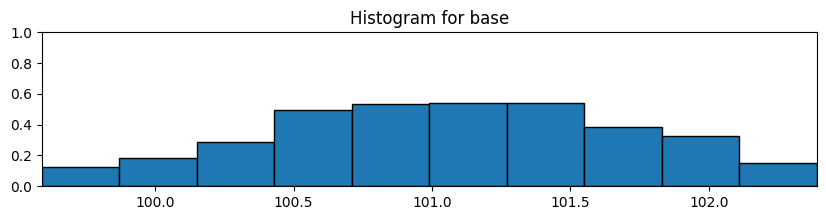

Использование инструментов заполнения пропусков с метрикой MSE
Mean: 0.833634315433405


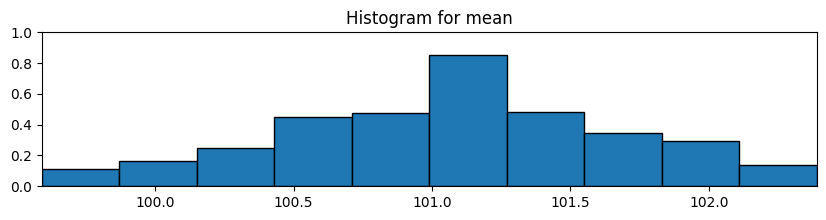

Median: 0.8341616795005447


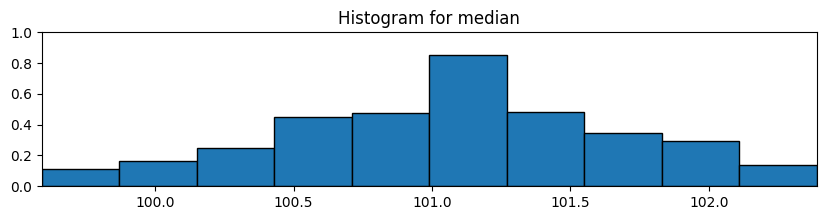

Mode: 0.8388071325760033
Mean between neighbours: 0.0343354188931207


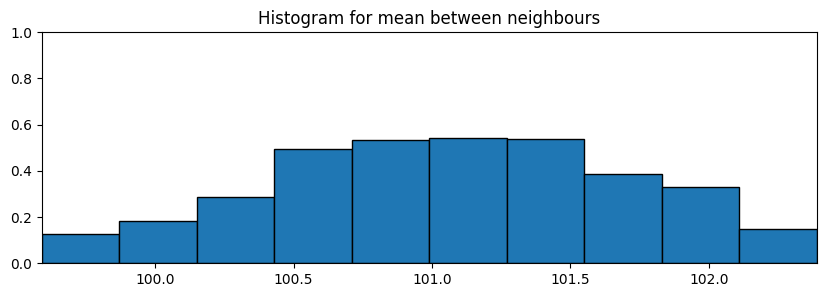

KNN: 0.683843514008098


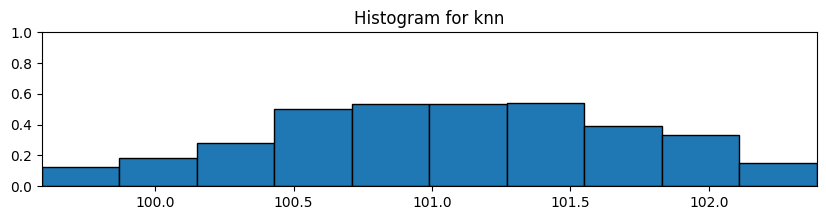

STD: 0.8439567024167486


In [11]:
import copy
import gc
DataV=copy.deepcopy(data)
Numbers=sum([([i]if np.random.rand()>0.9 else []) for i in range(1,DataV.shape[0]-1)],[])

left=data['Press_kPa'].quantile(0.05)
right = data['Press_kPa'].quantile(0.95)

plt.figure(figsize=(10, 2))
plt.hist(data['Press_kPa'], density=True, edgecolor='black',
         range=[left,right])
plt.xlim([left,right])
plt.ylim([0,1])
plt.title('Histogram for base')
plt.show()




def MSE(a,b,n):
  c=a-b
  return np.sqrt((c*c).sum()/n)

print("Использование инструментов заполнения пропусков с метрикой MSE")

N=len(Numbers)
DataV.iloc[Numbers,6]=np.nan
DataV.fillna(DataV.Press_kPa.mean(),inplace=True)
print("Mean:",MSE(DataV.Press_kPa.values,data.Press_kPa.values,N))



plt.figure(figsize=(10, 2))
plt.hist(DataV['Press_kPa'], density=True, edgecolor='black',
         range=[left,right])
plt.xlim([left,right])
plt.ylim([0,1])
plt.title('Histogram for mean')
plt.show()



DataV.iloc[Numbers,6]=np.nan
DataV.fillna(DataV.Press_kPa.median(),inplace=True)
print("Median:",MSE(DataV.Press_kPa.values,data.Press_kPa.values,N))


plt.figure(figsize=(10, 2))
plt.hist(DataV['Press_kPa'], density=True, edgecolor='black',
         range=[left,right])
plt.xlim([left,right])
plt.ylim([0,1])
plt.title('Histogram for median')
plt.show()


DataV.iloc[Numbers,6]=np.nan
DataV.fillna(DataV.Press_kPa.mode()[0],inplace=True)
print("Mode:",MSE(DataV.Press_kPa.values,data.Press_kPa.values,N))


DataV.iloc[Numbers,6]=np.nan
for i in range(DataV.shape[0]-1):
  if (np.isnan(DataV.loc[i,"Press_kPa"])):
    if(i==0 or i>0 and np.isnan(DataV.loc[i-1,"Press_kPa"])):
      DataV.loc[i,"Press_kPa"]=DataV.loc[i+1,"Press_kPa"]
    else:
      if(i==DataV.shape[0] or i<DataV.shape[0] and np.isnan(DataV.loc[i+1,"Press_kPa"])):
        DataV.loc[i,"Press_kPa"]=DataV.loc[i-1,"Press_kPa"]
      else:
        DataV.loc[i,"Press_kPa"]=(DataV.loc[i-1,"Press_kPa"]+DataV.loc[i+1,"Press_kPa"])/2

print("Mean between neighbours:",MSE(DataV.Press_kPa.values,data.Press_kPa.values,N))

plt.figure(figsize=(10, 3))
plt.hist(DataV['Press_kPa'], density=True, edgecolor='black',
         range=[left,right])
plt.xlim([left,right])
plt.ylim([0,1])
plt.title('Histogram for mean between neighbours')
plt.show()


DataV.iloc[Numbers,6]=np.nan
DataV=DataV.drop(columns=['Date/Time','Weather'])
imputer = KNNImputer(n_neighbors=2)
data_filled = imputer.fit_transform(DataV)
data_filled = pd.DataFrame(data_filled, columns=DataV.columns)
print("KNN:",MSE(data_filled['Press_kPa'].values,data.Press_kPa.values,N))

plt.figure(figsize=(10, 2))
plt.hist(DataV['Press_kPa'], density=True, edgecolor='black',
         range=[left,right])
plt.xlim([left,right])
plt.ylim([0,1])
plt.title('Histogram for knn')
plt.show()

del DataV
gc.collect()

print("STD:",np.std(data.Press_kPa))

## Анализ сгенерированных данных из нормального распределения

# Генерация данных и используемых далее функций:

In [12]:
import random
def analize(Axis,id,it,X,lable,D):
  n=len(X)
  Axis[id].step(np.concatenate((np.array([np.min(D)]),X,np.array([np.max(D)]))),np.concatenate((np.zeros(1),np.arange(1,n+1)/n,np.ones(1))),label=lable)
  Axis[id].set_xlim(np.min(D),np.max(D))

#Creating of the arrays
GData=np.empty((3,5000))
for i in range(3):
  GData[i]=np.random.normal(loc=5*np.sin(np.pi*i/3*2),scale=np.exp(i),size=5000)

GData1=np.empty((3,100))
for i in range(3):
  GData1[i]=np.random.normal(loc=5*np.sin(np.pi*i/3*2),scale=np.exp(i),size=100)

labels=[str(round(5*np.sin(np.pi*i/3*2),2))+" "+str(round(np.exp(i),2)) for i in range(3)]

In [13]:
import torch
import torch.nn as nn

# тензор x в программе не менять
x = torch.tensor([1,2,3,4,5,6,7,8,9,0,11,12,13,14,15,16], dtype=torch.float32)
layer=nn.Linear(16,1)
layer.weight.data=torch.ones(1,16)
layer.bias.data=torch.zeros(1)
# здесь продолжайте программу
layer.forward(x),x,layer.bias,layer.weight

(tensor([126.], grad_fn=<ViewBackward0>),
 tensor([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9.,  0., 11., 12., 13., 14.,
         15., 16.]),
 Parameter containing:
 tensor([0.], requires_grad=True),
 Parameter containing:
 tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]],
        requires_grad=True))

In [14]:
def quicksort_lv(arr):
    if len(arr) <= 1: return arr
    pivot = random.choice(arr)
    left = [x for x in arr if x < pivot]
    right = [x for x in arr if x > pivot]
    return quicksort_lv(left) + [pivot] + quicksort_lv(right)

# Анализ сгенерированнных данных:

Среднее: 0.0 Среднеквадратичное отклонение: 1.0
Среднее: 4.330127018922194 Среднеквадратичное отклонение: 2.718281828459045
Среднее: -4.330127018922192 Среднеквадратичное отклонение: 7.38905609893065


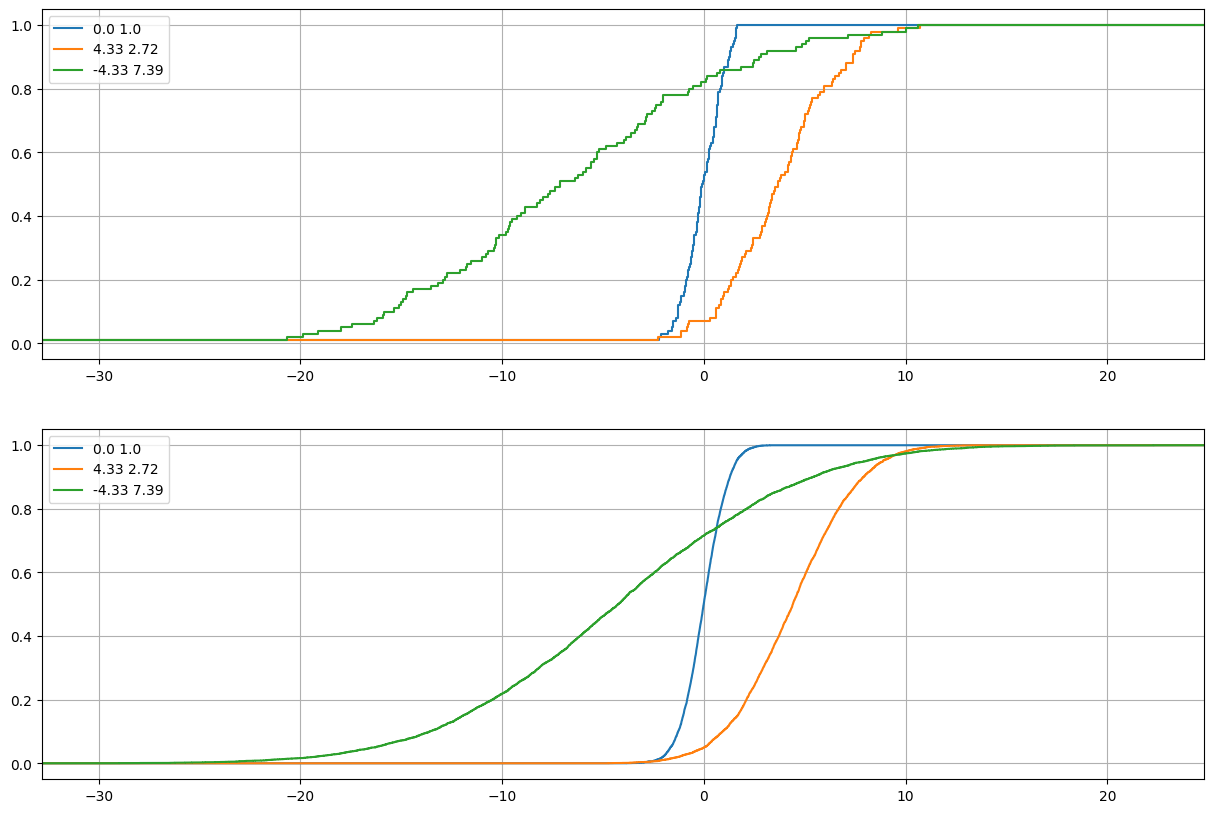

In [15]:
import random
for i in range(3):
  print("Среднее:",5*np.sin(np.pi*i/3*2),"Среднеквадратичное отклонение:",np.exp(i))
a,b=plt.subplots(nrows=2,ncols=1,figsize=(15,10))

for i in range(3):
  analize(b,0,0,np.sort(GData1[i]),labels[i],GData)
  analize(b,1,0,np.sort(GData[i]),labels[i],GData)
b[0].legend()
b[0].grid(True)
b[1].grid(True)
b[1].legend()
plt.show()

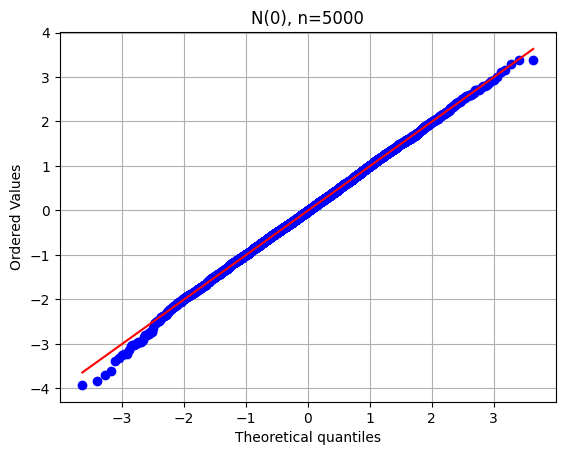

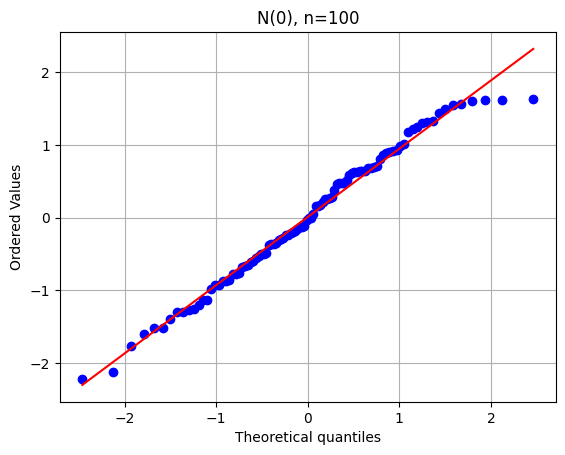

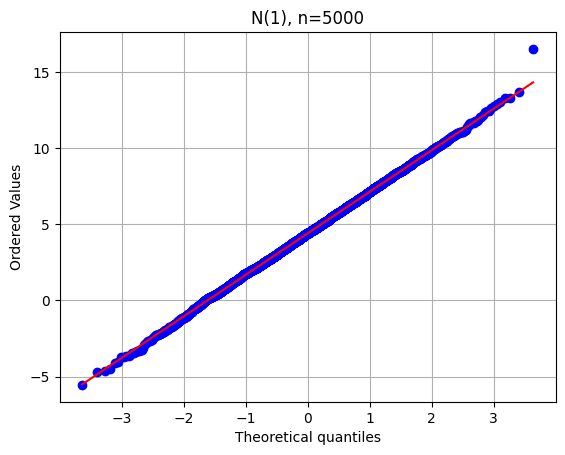

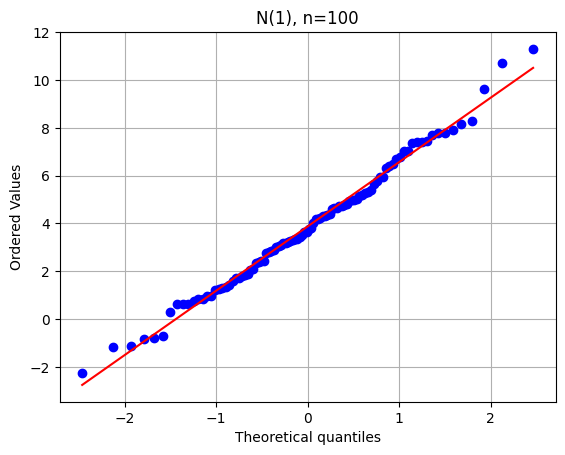

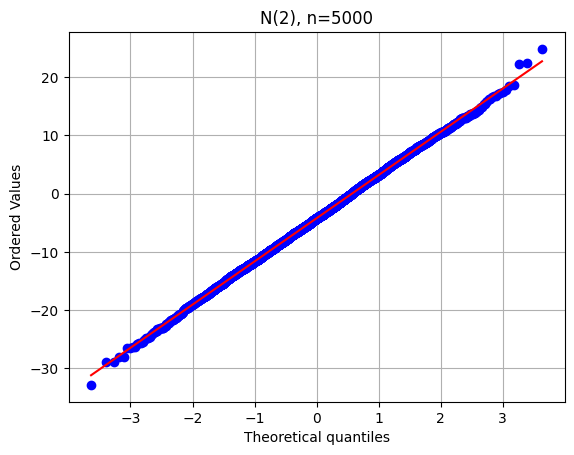

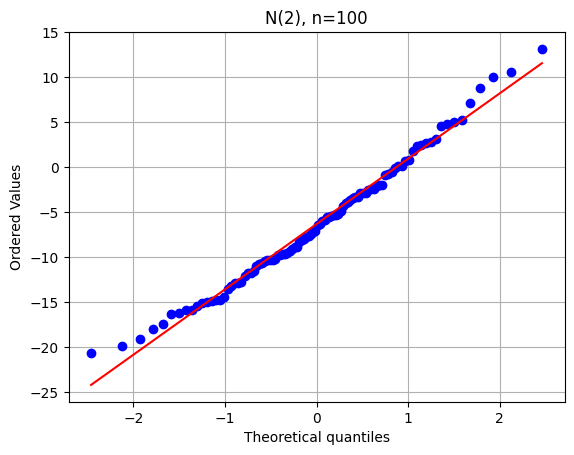

In [16]:

for i in range(3):
  stats.probplot(GData[i], dist="norm", plot=plt)
  plt.title("N({}), n={}".format(i,5000))

  plt.grid(True)
  plt.show()

  stats.probplot(GData1[i], dist="norm", plot=plt)

  plt.title("N({}), n={}".format(i,100))
  plt.grid(True)
  plt.show()


/tmp/ipython-input-3792805374.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


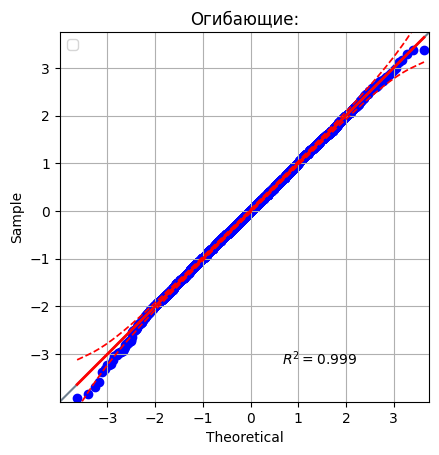

/tmp/ipython-input-3792805374.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


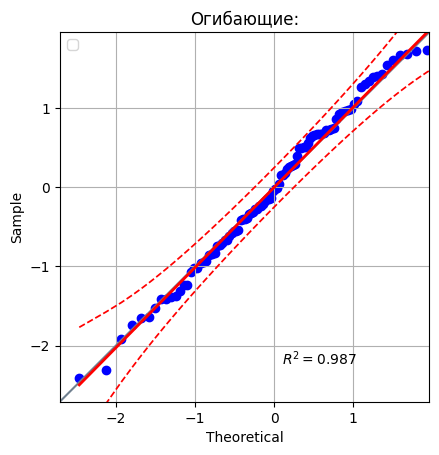

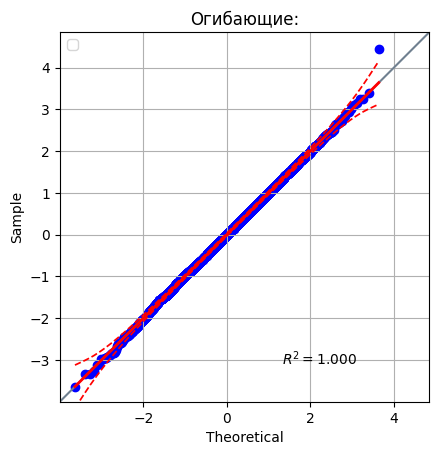

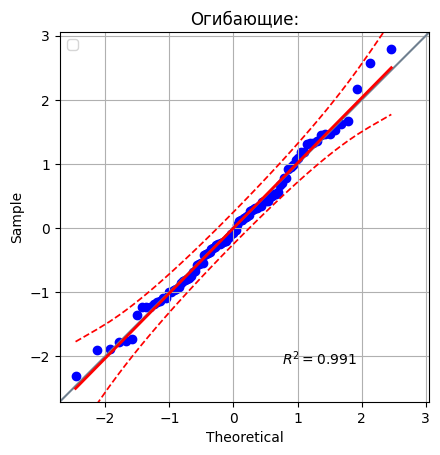

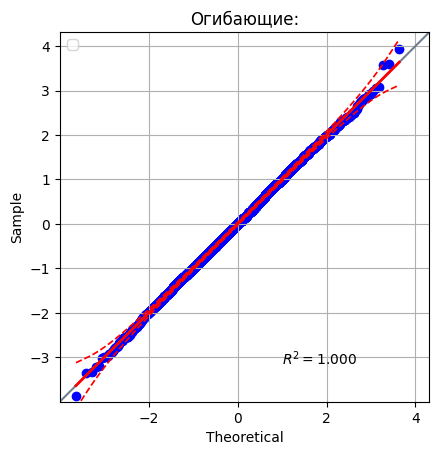

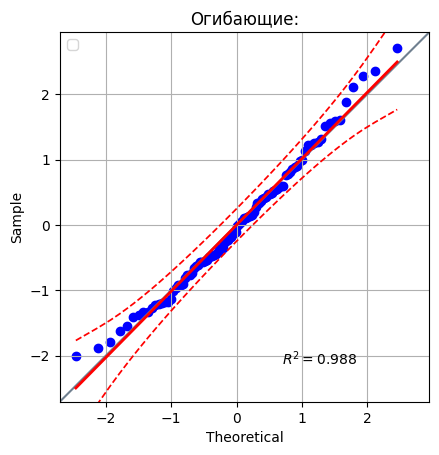

In [17]:
import numpy as np
import matplotlib.pyplot as plt

prob_levels = np.linspace(0.01, 0.99, 99)
theoretical_quantiles =stats.norm.ppf(prob_levels, loc=0, scale=1)
sample_quantiles = np.quantile((GData[0]-GData[0].mean())/GData[0].std(), prob_levels)

points=np.array([(theoretical_quantiles[i],sample_quantiles[i])for i in range(len(prob_levels))])


for i in range(3):
  pg.qqplot(GData[i], dist='norm', confidence=0.95)
  plt.xlabel('Theoretical')
  plt.ylabel('Sample')
  plt.title('Огибающие:')
  plt.legend()
  plt.grid(True)
  plt.show()

  pg.qqplot(GData1[i], dist='norm', confidence=0.95)
  plt.xlabel('Theoretical')
  plt.ylabel('Sample')
  plt.title('Огибающие:')
  plt.legend()
  plt.grid(True)
  plt.show()

# Проверка гипотез о нормальности распределения:

In [18]:
def normal_test(df,alpha):
  res = pd.Series(np.zeros(6),index=["Колмогорова-Смирнова","ШапироУилка","Андерсона-Дарлинга",
                                     "Крамера фон Мизеса","Колмогорова-Смирнова в модификации Лиллиефорса","Шапиро-Франсия"])
  result = stats.kstest(df, 'norm', args=(np.mean(df), np.std(df,ddof=1)))
  res.loc["Колмогорова-Смирнова"]=1 if result.pvalue>alpha else 0

  result = stats.shapiro(df)
  res.loc["ШапироУилка"]=1 if result.pvalue>alpha else 0

  result = stats.anderson(df, dist='norm')
  res.loc["Андерсона-Дарлинга"]=1 if result.statistic<=result.critical_values[list(result.significance_level).index(int(alpha*100))] else 0

  result = stats.cramervonmises((df-df.mean())/df.std(), 'norm')
  res.loc["Крамера фон Мизеса"]=1 if result.pvalue > alpha else 0

  from statsmodels.stats.diagnostic import lilliefors
  a,p_value = lilliefors(df)
  res.loc["Колмогорова-Смирнова в модификации Лиллиефорса"]=1 if p_value > alpha else 0

  statistic, p_value = stats.shapiro(df)
  res.loc["Шапиро-Франсия"]=1 if p_value > alpha else 0
  return res

In [19]:
def normal_test_pvalues(df):
    import numpy as np
    from scipy import stats
    from statsmodels.stats.diagnostic import lilliefors
    import pandas as pd

    res = pd.Series(np.zeros(6), index=[
        "Колмогорова-Смирнова",
        "Шапиро-Уилка",
        "Андерсона-Дарлинга",
        "Крамера-фон-Мизеса",
        "Лиллиефорса",
        "Шапиро-Франсия"
    ])

    result = stats.kstest(df, 'norm', args=(np.mean(df), np.std(df, ddof=1)))
    res.loc["Колмогорова-Смирнова"] = result.pvalue

    result = stats.shapiro(df)
    res.loc["Шапиро-Уилка"] = result.pvalue

    result = stats.anderson(df, dist='norm')
    res.loc["Андерсона-Дарлинга"] = result.statistic

    result = stats.cramervonmises((df - df.mean()) / df.std(), 'norm')
    res.loc["Крамера-фон-Мизеса"] = result.pvalue

    _, p_value = lilliefors(df)
    res.loc["Лиллиефорса"] = p_value

    statistic, p_value = stats.shapiro(df)
    res.loc["Шапиро-Франсия"] = p_value

    return res

In [20]:
from scipy import stats
print("Проверка критериев с уровнем значимости alpha=0.05 на сгенерированных данных:")
alpha=0.05
res=pd.DataFrame([(normal_test(GData[i],alpha) if i<3 else normal_test(GData1[i-3],alpha)) for i in range(6)])

res

Проверка критериев с уровнем значимости alpha=0.05 на сгенерированных данных:


,Колмогорова-Смирнова,ШапироУилка,Андерсона-Дарлинга,Крамера фон Мизеса,Колмогорова-Смирнова в модификации Лиллиефорса,Шапиро-Франсия
0,1.0,1.0,1.0,1.0,1.0,1.0
1,1.0,1.0,1.0,1.0,1.0,1.0
2,1.0,1.0,1.0,1.0,1.0,1.0
3,1.0,1.0,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,1.0,1.0,1.0
5,1.0,1.0,1.0,1.0,1.0,1.0


In [23]:
print("P-value критериев проверки нормальности для сгенерированных данных:")
res = pd.DataFrame([normal_test_pvalues(GData[i]) if i < 3 else normal_test_pvalues(GData1[i-3]) for i in range(6)])
print(res)

P-value критериев проверки нормальности для сгенерированных данных:
   Колмогорова-Смирнова  Шапиро-Уилка  Андерсона-Дарлинга  Крамера-фон-Мизеса  \
0              0.970967      0.151967            0.274052            0.951009   
1              0.789830      0.864656            0.226545            0.974366   
2              0.964616      0.895335            0.276349            0.926265   
3              0.698898      0.160072            0.371956            0.842748   
4              0.975453      0.716258            0.246080            0.962366   
5              0.859331      0.368818            0.311884            0.905519   

   Лиллиефорса  Шапиро-Франсия  
0     0.822904        0.151967  
1     0.401133        0.864656  
2     0.798554        0.895335  
3     0.286205        0.160072  
4     0.862314        0.716258  
5     0.537163        0.368818  


# Анализ естественных данных:

Проверка критериев с уровнем значимости alpha=0.05 на реальных данных:


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8784.
  res = hypotest_fun_out(*samples, **kwds)


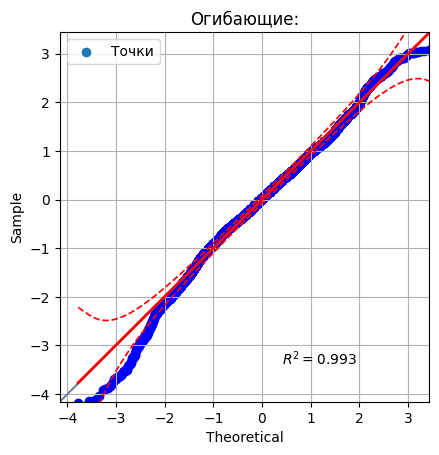

,Колмогорова-Смирнова,ШапироУилка,Андерсона-Дарлинга,Крамера фон Мизеса,Колмогорова-Смирнова в модификации Лиллиефорса,Шапиро-Франсия
0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
print("Проверка критериев с уровнем значимости alpha=0.05 на реальных данных:")
alpha=0.05
NN=1
i=0
Data=np.array([data.Press_kPa.values])
res=pd.DataFrame([normal_test(Data[i],alpha)  for i in range(NN)])


prob_levels = np.linspace(0.01, 0.99, 99)
theoretical_quantiles =stats.norm.ppf(prob_levels, loc=0, scale=1)
DData=np.array(data["Press_kPa"].values)
sample_quantiles = np.quantile((DData-DData.mean())/DData.std(), prob_levels)

points=np.array([(theoretical_quantiles[i],sample_quantiles[i])for i in range(len(prob_levels))])
#hull_points = convex_hull(points)

plt.scatter(points[:, 0], points[:, 1], label='Точки')
#hull_points = np.array(hull_points + [hull_points[0]])
#plt.plot(hull_points[:, 0], hull_points[:, 1], 'r-', lw=2, label='Оболочка')
pg.qqplot(DData, dist='norm', confidence=0.999999999)


plt.xlabel('Theoretical')
plt.ylabel('Sample')
plt.title('Огибающие:')
plt.legend()
plt.grid(True)
plt.show()

res

In [25]:
print("P-value критериев проверки нормальности для реальных данных (Press_kPa):")
res = pd.DataFrame([normal_test_pvalues(Data[i]) for i in range(NN)])
print(res)

prob_levels = np.linspace(0.01, 0.99, 99)
theoretical_quantiles = stats.norm.ppf(prob_levels, loc=0, scale=1)
DData = np.array(data["Press_kPa"].values)
sample_quantiles = np.quantile((DData - DData.mean()) / DData.std(), prob_levels)
points = np.array([(theoretical_quantiles[i], sample_quantiles[i]) for i in range(len(prob_levels))])



P-value критериев проверки нормальности для реальных данных (Press_kPa):
   Колмогорова-Смирнова  Шапиро-Уилка  Андерсона-Дарлинга  Крамера-фон-Мизеса  \
0          7.252663e-10  1.281843e-20           13.468486            0.000014   

   Лиллиефорса  Шапиро-Франсия  
0        0.001    1.281843e-20  


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8784.
  res = hypotest_fun_out(*samples, **kwds)


[ 97.52  97.56  97.58 ... 103.65 103.65 103.65]


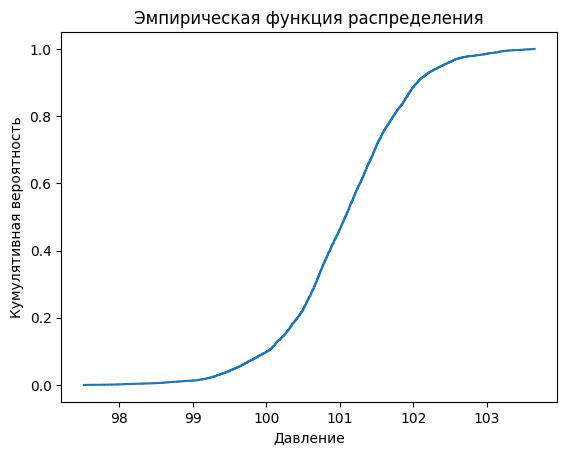

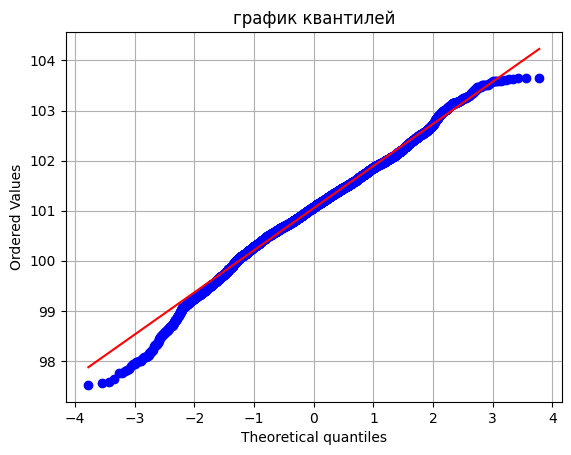

In [22]:
data_sorted = np.sort(Data)
data_sorted=data_sorted.reshape(data_sorted.size)
print(data_sorted)
y = np.arange(1, len(data_sorted) + 1) / len(data_sorted)

plt.step(data_sorted, y, where='post')
plt.xlabel('Давление')
plt.ylabel('Кумулятивная вероятность')
plt.title('Эмпирическая функция распределения')
plt.show()

stats.probplot(Data.reshape(Data.size), dist="norm", plot=plt)
plt.title("график квантилей")
plt.grid(True)
plt.show()


диаграмма заполнений, knn, огибающие